# Детекция аномалий в числовых данных: критерий Неймана–Пирсона и закон Бенфорда

**Идея.** В естественно возникающих числовых данных (финансовые показатели, население, физические величины) первая значащая цифра распределена не равномерно, а по закону Бенфорда: цифра 1 встречается в ~30% случаев, цифра 9 — в ~4.6%. Сфабрикованные данные обычно этому закону не следуют — на этом основаны методы детекции фальсификаций в финансовом аудите и антифроде.

**Задача.** Построить наиболее мощный критерий (Неймана–Пирсона) для различения гипотез:
- $H_0$: первые цифры следуют закону Бенфорда (данные «честные»),
- $H_1$: первые цифры распределены равномерно (модель подделки),

оценить его мощность симуляцией и применить к реальным данным — ВВП всех стран мира (World Bank Open Data).

## Данные и первая значащая цифра

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


In [14]:
rng = np.random.default_rng(0)
ALPHA = 0.05

df = pd.read_csv("../data/benford_data.csv")
print("Всего чисел:", len(df))
print(df.dataset.value_counts().to_string())

digits = np.arange(1, 10)
benford = np.log10(1 + 1/digits)         # теоретические вероятности Бенфорда p^0_d
uniform = np.ones(9) / 9                  # равномерное распределение цифр p^1_d (модель подделки)
print("\nЗакон Бенфорда:", np.round(benford, 3))


Всего чисел: 18887
dataset
gdp                13979
city_population     4908

Закон Бенфорда: [0.301 0.176 0.125 0.097 0.079 0.067 0.058 0.051 0.046]


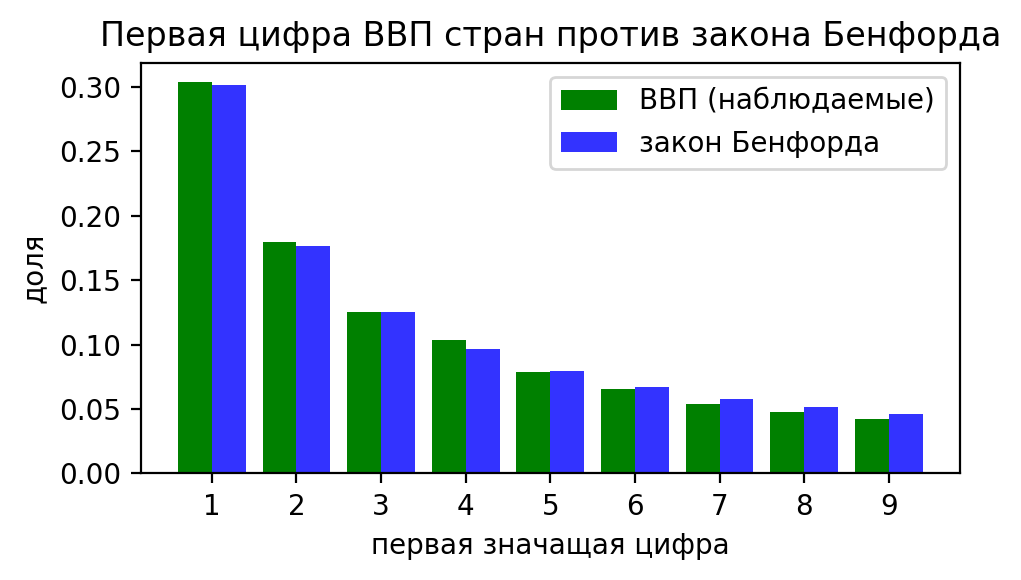

Наблюдаемые доли (ВВП): [0.303 0.179 0.126 0.103 0.079 0.066 0.054 0.048 0.042]


In [15]:
def first_digit(x):
    x = abs(float(x))
    if x == 0:
        return None
    while x < 1:  x *= 10
    while x >= 10: x /= 10
    return int(x)

gdp_vals = df.loc[df.dataset == "gdp", "value"].values
fd = np.array([first_digit(v) for v in gdp_vals])
obs_gdp = np.array([(fd == d).sum() for d in digits])


fig, ax = plt.subplots(figsize=(5, 3), dpi=200)
w = 0.4
ax.bar(digits - w/2, obs_gdp/obs_gdp.sum(), w, color="green", label="ВВП (наблюдаемые)")
ax.bar(digits + w/2, benford, w, color="blue", alpha=0.8, label="закон Бенфорда")
ax.set_xticks(digits); ax.set_xlabel("первая значащая цифра"); ax.set_ylabel("доля")
ax.legend(); ax.set_title("Первая цифра ВВП стран против закона Бенфорда")
plt.tight_layout(); plt.show()
print("Наблюдаемые доли (ВВП):", np.round(obs_gdp/obs_gdp.sum(), 3))


Наблюдаемые частоты первых цифр ВВП визуально хорошо ложатся на закон Бенфорда — убывание от цифры 1 к цифре 9.

## Логарифмическое отношение правдоподобия

По лемме Неймана–Пирсона наиболее мощный критерий отвергает $H_0$ при больших значениях статистики
$T = \sum_i \ell(X_i)$, где $\ell(d) = \ln\big(p^1_d / p^0_d\big)$ — вклад цифры $d$ в лог-отношение правдоподобия. Положительный $\ell(d)$ — улика в пользу подделки, отрицательный — в пользу честности.

In [16]:
#Вклад каждой цифры в улику: l(d) = ln( p1_d / p0_d )

def llr_per_digit(): #log-likelihood ratio
    return np.log(uniform / benford)

ell = llr_per_digit()
print("Вклад каждой цифры в log-LR (l(d)):")
for d in digits:
    sign = "→ улика за подделку" if ell[d-1] > 0 else "→ улика за честность"
    print(f"  цифра {d}: l={ell[d-1]:+.3f}  {sign}")


Вклад каждой цифры в log-LR (l(d)):
  цифра 1: l=-0.997  → улика за честность
  цифра 2: l=-0.460  → улика за честность
  цифра 3: l=-0.117  → улика за честность
  цифра 4: l=+0.137  → улика за подделку
  цифра 5: l=+0.339  → улика за подделку
  цифра 6: l=+0.507  → улика за подделку
  цифра 7: l=+0.650  → улика за подделку
  цифра 8: l=+0.776  → улика за подделку
  цифра 9: l=+0.887  → улика за подделку


## Распределение статистики, порог и мощность

Точное распределение $T$ громоздко, поэтому порог $c'$ (квантиль уровня $1-\alpha$ распределения $T$ при $H_0$) и мощность оцениваются методом Монте-Карло.

In [17]:
 # Статистика T и её распределение при H0 и H1
def np_statistic(values):
    ell = llr_per_digit()
    fd = np.array([first_digit(v) for v in values if first_digit(v) is not None])
    return ell[fd - 1].sum()

def sample_digits(probs, n, rng):
    """n первых цифр из распределения probs (длины 9, цифры 1..9)."""
    return rng.choice(digits, size=n, p=probs)

n = 200          # размер проверяемой выборки
M = 20000        # число симуляций
ell = llr_per_digit()
# распределение T при H0 (Benford) и при H1 (Uniform):
T0 = np.array([ell[sample_digits(benford, n, rng) - 1].sum() for _ in range(M)])
T1 = np.array([ell[sample_digits(uniform, n, rng) - 1].sum() for _ in range(M)])
print("Среднее T при H0:", round(T0.mean(), 2), "| при H1:", round(T1.mean(), 2))

EH0 = (benford * ell).sum()   # это -KL(p0||p1)
EH1 = (uniform * ell).sum()   # это +KL(p1||p0)
print(f"E_H0[l] = {EH0:.3f} | E_H1[l] = {EH1:.3f}")


Среднее T при H0: -40.78 | при H1: 38.14
E_H0[l] = -0.204 | E_H1[l] = 0.191


In [18]:
#  Порог, фактическая ошибка I рода, мощность

threshold = np.quantile(T0, 1 - ALPHA)
alpha_hat = np.mean(T0 >= threshold)
power = np.mean(T1 >= threshold)

print(f"Порог c' (при alpha={ALPHA}):      {threshold:.3f}")
print(f"Фактическая ошибка I рода:        {alpha_hat:.3f}  (должна быть ≈ {ALPHA})")
print(f"Мощность против подделки (n={n}): {power:.3f}")


Порог c' (при alpha=0.05):      -25.800
Фактическая ошибка I рода:        0.050  (должна быть ≈ 0.05)
Мощность против подделки (n=200): 1.000


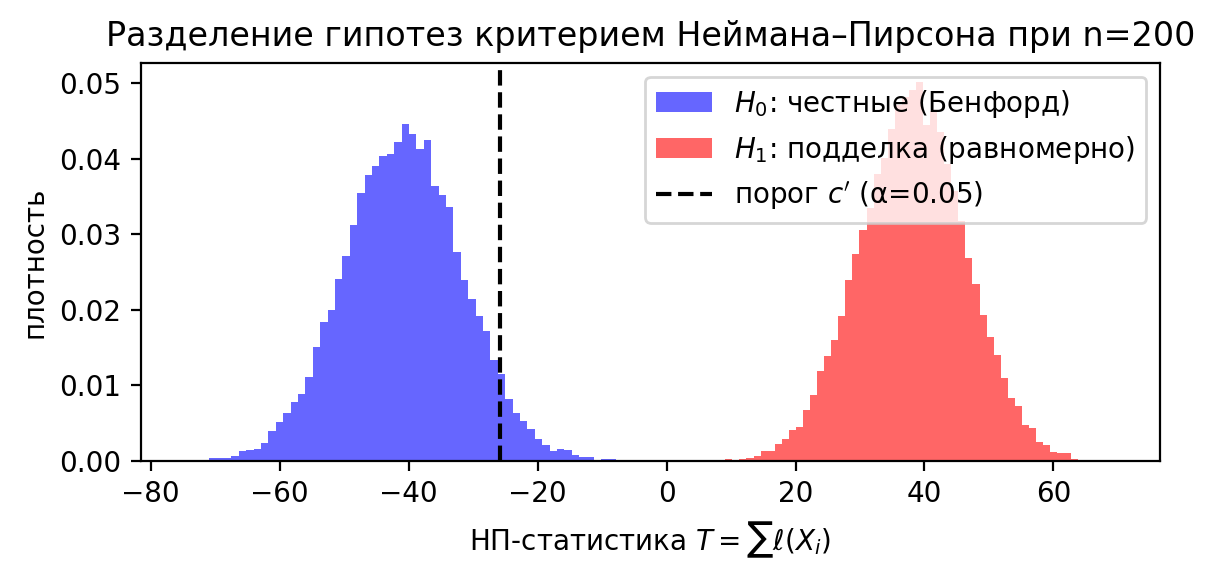

In [19]:
# Распределения статистики T при H0 и H1 + порог
fig, ax = plt.subplots(figsize=(6, 3), dpi= 200)
ax.hist(T0, bins=60, density=True, alpha=0.6, color="blue", label="$H_0$: честные (Бенфорд)")
ax.hist(T1, bins=60, density=True, alpha=0.6, color="red", label="$H_1$: подделка (равномерно)")
ax.axvline(threshold, color="black", ls="--", label=f"порог $c'$ (α={ALPHA})")
ax.set_xlabel("НП-статистика $T=\\sum \\ell(X_i)$"); ax.set_ylabel("плотность")
ax.set_title(f"Разделение гипотез критерием Неймана–Пирсона при n={n}"); ax.legend()
plt.tight_layout(); plt.show()


При $n = 200$ распределения статистики под $H_0$ и $H_1$ разделяются практически полностью: фактическая ошибка I рода совпадает с заданным $\alpha = 0.05$, мощность близка к 1.

## Мощность как функция объёма выборки

Сколько чисел нужно проверить, чтобы уверенно поймать фальсификацию? Строим кривую мощности по $n$.

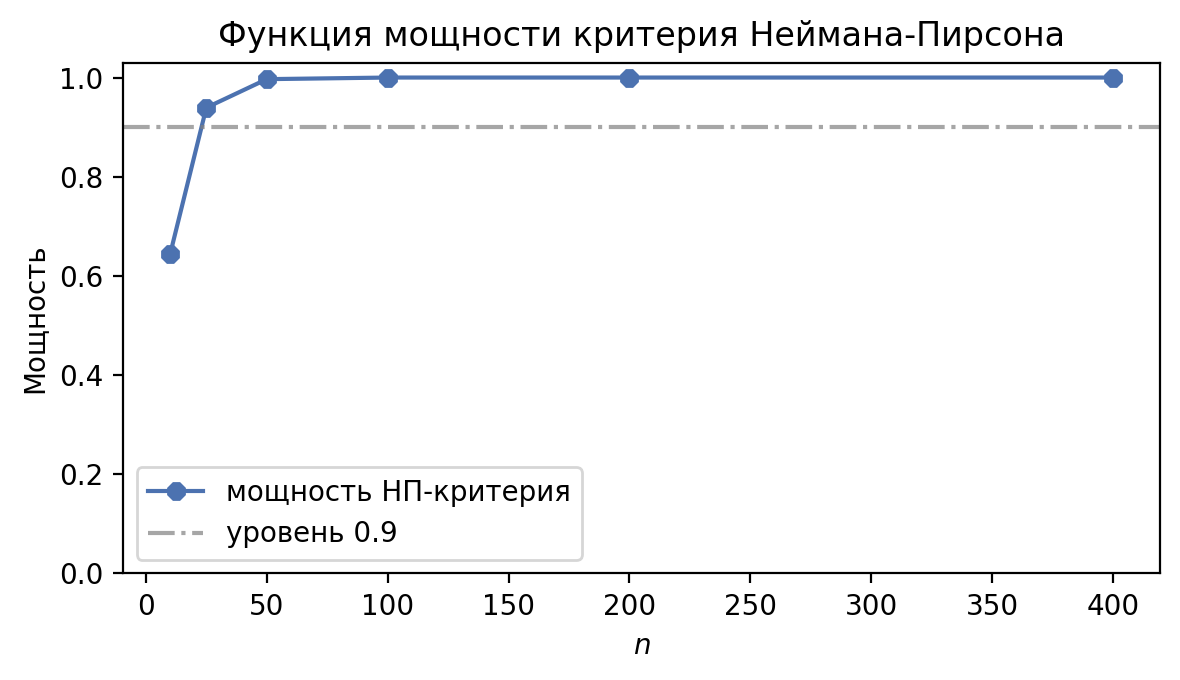

При n =  10 имеем мощность = 0.643
При n =  25 имеем мощность = 0.939
При n =  50 имеем мощность = 0.997
При n = 100 имеем мощность = 1.000
При n = 200 имеем мощность = 1.000
При n = 400 имеем мощность = 1.000


In [20]:
# Функция мощности: мощность как функция размера выборки n

ns = [10, 25, 50, 100, 200, 400]
M2 = 4000
ell = llr_per_digit()

powers = []
for nn in ns:
  T0 = np.empty(M2)
  T1 = np.empty(M2)
  for i in range(M2):
      digits_benford = sample_digits(benford, nn, rng) #генерируем выборку для закона Бенфорда, берем нужные индексы и суммируем
      T0[i] = ell[digits_benford - 1].sum()
      digits_uniform = sample_digits(uniform, nn, rng) #генерируем выборку для равномерного распределения, берем нужные индексы и суммируем
      T1[i] = ell[digits_uniform - 1].sum()
  thr = np.quantile(T0, 1 - ALPHA)
  powers.append(np.mean(T1 >= thr))                    #мощность = доля подделок выше порога
powers = np.array(powers)

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=200)
ax.plot(ns, powers, "8-", color="#4C72B0", lw=1.5, label="мощность НП-критерия")
ax.axhline(0.9, color="gray", ls="dashdot", alpha=0.7, label="уровень 0.9")
ax.set_xlabel("$n$")
ax.set_ylabel("Мощность")
ax.set_title("Функция мощности критерия Неймана-Пирсона")
ax.set_ylim(0, 1.03)
ax.legend()
plt.tight_layout()
plt.show()

for nn, pw in zip(ns, powers):
    print(f"При n ={nn:4d} имеем мощность = {pw:.3f}")


## Проверка реальных данных: ВВП стран мира

In [21]:
#  Решение на реальных данных (ВВП)
N = len(gdp_vals)
T_obs = np_statistic(gdp_vals)                       # наблюдаемая статистика на реальных данных
ell = llr_per_digit()
T0_real = np.array([ell[sample_digits(benford, N, rng) - 1].sum() for _ in range(5000)])

threshold_real = np.quantile(T0_real, 1 - ALPHA)
reject = bool(T_obs >= threshold_real)

print(f"Границы облака H0: min={T0_real.min():.0f}, центр={T0_real.mean():.0f}, max={T0_real.max():.0f}")

print(f"ВВП: N={N}, T_набл = {T_obs:.2f}, порог c' = {threshold_real:.2f}")
print(f"Отвергаем H0 (данные похожи на подделку)? {reject}")


Границы облака H0: min=-3117, центр=-2850, max=-2571
ВВП: N=13979, T_набл = -3022.35, порог c' = -2722.40
Отвергаем H0 (данные похожи на подделку)? False


## Выводы

- Критерий Неймана–Пирсона строится напрямую из отношения правдоподобия; порог и мощность корректно оцениваются симуляцией.
- Мощность быстро растёт с $n$: уже на выборках порядка сотни чисел равномерная «подделка» отлавливается почти наверняка.
- Реальные данные ВВП критерием не отвергаются — наблюдаемая статистика лежит глубоко внутри облака $H_0$, т.е. данные согласуются с законом Бенфорда.
- Тот же пайплайн применим к аудиту транзакций и антифроду: подставьте свои числа вместо ВВП.